# Clasificacion de riesgo de fallecimiento intrahospitalario - Egresos Hospitalarios Ecuador 2024

**Objetivo:** predecir, con variables disponibles al momento del ingreso, el riesgo de que un egreso hospitalario
termine en fallecimiento (`con_egrpa`).

**Variable objetivo:** `con_egrpa` -> se recodifica a binaria:
- `0` = `Vivo`
- `1` = `Fallecido menos de 48 horas` o `Fallecido en 48 horas y más`

**Decisiones de diseno y hallazgos de la exploracion de la muestra (`muestra_para_ia.csv`) que debes conocer:**

1. **Fuga de informacion (obligatorio, por tus restricciones):** se eliminan `dia_estad` y cualquier variable de la
   fecha de egreso (`anio_egr`, `mes_egr`, `dia_egr`, `fecha_egr`), porque solo se conocen al final de la
   hospitalizacion.
2. **Fuga de informacion adicional detectada (recomendacion de Data Scientist, revisa y decide):**
   - `esp_egrpa` (especialidad **de egreso**) - por su nombre y semantica no esta garantizado que se conozca al
     ingreso (puede cambiar durante la estancia, p. ej. traslado a UCI/Cirugia). Se excluye por defecto. Si en tu
     fuente de datos esta especialidad es en realidad la de *admision*, puedes moverla a `CATEGORICAL_FEATURES` en
     la celda de configuracion.
   - `cau_cie10` y `causa3` (diagnostico CIE-10 muy granular, ~150-200 categorias en una muestra de 300 filas) se
     excluyen del modelo por alto riesgo de sobreajuste / explosion dimensional en One-Hot Encoding, y porque el
     diagnostico definitivo de un registro de egreso hospitalario en Ecuador (INEC) usualmente se termina de
     codificar al alta. Se usa en su lugar la agrupacion de mayor jerarquia `cap221rx` (capitulo CIE-10, ~19
     categorias) y `cau221rx` (grupo de causas, ~89 categorias), mas estables y representativas de comorbilidades /
     motivo de ingreso conocido tempranamente. Ajusta esta decision segun el conocimiento clinico del dominio: si
     el diagnostico de ingreso (no el de egreso) esta disponible en tu sistema, puedes reincorporar
     `cau_cie10`/`causa3`.
3. **Error de unidades en la edad:** la columna `edad` esta en la unidad indicada por `cod_edad` (Horas, Dias, Meses
   o Anos). Mezclar estos valores sin normalizar (p. ej. un recien nacido de 1 hora vs. un paciente de 1 ano)
   introduce un sesgo severo. Se construye una variable continua `edad_anios` que homogeniza todo a anos.
4. **Columnas redundantes / no informativas:** `nom_pais` y `cod_pais` son redundantes con `nac_pac`; `mes_inv`
   (mes de reporte/investigacion estadistica INEC) es distinto y en ~19% de los casos difiere de `mes_ingr`, pero no
   aporta valor clinico y se descarta; `parr_ubi`/`parr_res` (parroquia) tienen cardinalidad demasiado alta para
   One-Hot a nivel nacional y se resumen con `cant_ubi`/`cant_res` (canton); `anio_ingr` no tiene varianza dentro de
   un unico ano de datos.
5. Todas estas listas estan centralizadas en la celda de **configuracion** para que las ajustes con un clic.

> Ejecuta las celdas en orden. Este notebook fue validado logicamente contra la muestra de 300 filas; al correrlo
> contra `egresos_hospitalarios_2024.csv` completo, revisa los tiempos de entrenamiento de las redes neuronales y
> ajusta `N_TRIALS_TUNER` / `EPOCHS` si es necesario.

## 1. Instalacion de dependencias e imports

Descomentar la siguiente línea sólo si es la primera vez que se corre

In [ ]:
# %pip install pandas numpy scikit-learn imbalanced-learn tensorflow keras-tuner tensorboard matplotlib seaborn joblib


In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import (
    recall_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


## 2. Configuracion

Decisiones de columnas y de tiempo de entrenamiento.

In [4]:
DATA_PATH = "muestra_para_ia.csv" # path del dataset
CSV_SEP = ";"

TARGET_COL = "con_egrpa"
FALLECIDO_LABELS = ["Fallecido menos de 48 horas", "Fallecido en 48 horas y más"]
VIVO_LABEL = "Vivo"

# Columnas eliminadas por fuga de informacion
LEAKAGE_COLS = [
    "dia_estad",                                    # dias de estadia -> solo se conoce al egreso
    "anio_egr", "mes_egr", "dia_egr", "fecha_egr",  # fecha de egreso
    "esp_egrpa",                                    # especialidad de EGRESO
]

# Columnas redundantes / demasiado granulares / sin varianza -> se descartan
DROP_COLS = [
    "nom_pais", "cod_pais",     # redundantes con nac_pac
    "mes_inv",                  # mes de reporte estadistico, no clinico
    "parr_ubi", "parr_res",     # parroquia: cardinalidad excesiva a nivel nacional
    "cau_cie10", "causa3",      # CIE-10 muy granular -> riesgo de overfitting/leakage de diagnostico definitivo
    "cau298rx",                 # redundante con cau221rx (granularidad similar)
    "anio_ingr",                # sin varianza (un solo ano en 2024)
,     # derivados del diagnostico definitivo de egreso -> eliminados para evitar fuga de informacion
]

NUMERIC_FEATURES = ["edad_anios", "dia_ingr"]

CATEGORICAL_FEATURES = [
    "prov_ubi", "cant_ubi", "area_ubi", "clase", "tipo", "entidad", "sector",
    "nac_pac", "sexo", "etnia", "tipo_seg", "dis_pac",
    "prov_res", "cant_res", "area_res",
    "mes_ingr", "dow_ingr",
]

TEST_SIZE = 0.2
CV_FOLDS = 5
N_TRIALS_TUNER = 10     # busquedas de keras-tuner por modelo
EPOCHS = 60
BATCH_SIZE = 256
EARLY_STOP_PATIENCE = 8
MIN_OHE_FREQUENCY = 0.005  # categorias con frecuencia menor se agrupan en "infrequent" (evita explosion dimensional)


## 3. Carga de datos y exploracion inicial

In [5]:
df = pd.read_csv(DATA_PATH, sep=CSV_SEP)
print("Shape:", df.shape)
df.head()

Shape: (300, 38)


,prov_ubi,cant_ubi,parr_ubi,area_ubi,clase,tipo,entidad,sector,mes_inv,nac_pac,...,dia_egr,fecha_egr,dia_estad,con_egrpa,esp_egrpa,cau_cie10,causa3,cap221rx,cau221rx,cau298rx
0,Guayas,Guayaquil,Ximena,Urbana,Gineco-Obstétrico,Agudo,Ministerio de Salud Pública,Público,Abril,Ecuatoriano/a,...,20,2024-04-20,3,Vivo,Otra,P011 Feto y recién nacido afectados por ruptur...,P01 Feto y recién nacido afectados por compl...,XVI Ciertas afecciones originadas en el period...,"163 Feto, y recién nacido afectados por factor...",245 Feto y recién nacido afectado por factores...
1,Loja,Loja,Valle,Urbana,Hospital general,Agudo,Instituto Ecuatoriano de Seguridad Social,Público,Agosto,Ecuatoriano/a,...,3,2024-08-03,2,Vivo,Cirugía General,K802 Cálculo de la vesícula biliar sin colecis...,K80 Colelitiasis,XI Enfermedades del sistema digestivo (K00-K93),"119 Trastornos de la vesícula biliar, de vías ...",195 Colelitiasis y colecistitis
2,Guayas,Guayaquil,Febres Cordero,Urbana,Hospital de especialidades,Agudo,Ministerio de Salud Pública,Público,Septiembre,Ecuatoriano/a,...,7,2024-09-07,1,Fallecido menos de 48 horas,Cirugía General,A099 Gastroenteritis y colitis de origen no es...,A09 Otras gastroenteritis y colitis de orige...,I Ciertas enfermedades infecciosas y parasitar...,1 Enfermedades infecciosas intestinales (A00-A09),5 Diarrea y gastroenteritis de presunto rigen ...
3,Guayas,Guayaquil,Febres Cordero,Urbana,Hospital de especialidades,Agudo,Ministerio de Salud Pública,Público,Diciembre,Ecuatoriano/a,...,6,2024-12-06,9,Fallecido en 48 horas y más,Neurocirugía,I613 Hemorragia intraencefálica en tallo cerebral,I61 Hemorragia intraencefálica,IX Enfermedades del sistema circulatorio (I00-...,97 Enfermedades cerebrovasculares (I60-I69),153 Hemorragia intracraneal
4,Guayas,Guayaquil,Tarqui,Urbana,Hospital de especialidades,Agudo,Junta Beneficencia de Guayaquil,Privado sin fines de lucro,Abril,Ecuatoriano/a,...,18,2024-04-18,2,Vivo,Traumatología,M200 Deformidad de dedo(s) de la mano,M20 Deformidades adquiridas de los dedos de ...,XIII Enfermedades del sistema osteomuscular y ...,132 Otros trastornos articulares (M20-M25),202 Deformidades adquiridas de los miembros


In [6]:
print("Nulos por columna (top 15):")
print(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nDistribucion de la variable objetivo original:")
print(df[TARGET_COL].value_counts(dropna=False))


Nulos por columna (top 15):
prov_ubi      0
dia_egr       0
area_res      0
anio_ingr     0
mes_ingr      0
dia_ingr      0
fecha_ingr    0
anio_egr      0
mes_egr       0
fecha_egr     0
cant_ubi      0
dia_estad     0
con_egrpa     0
esp_egrpa     0
cau_cie10     0
dtype: int64

Distribucion de la variable objetivo original:
con_egrpa
Vivo                           100
Fallecido menos de 48 horas    100
Fallecido en 48 horas y más    100
Name: count, dtype: int64


## 4. Construccion de la variable objetivo binaria

`1` = fallecimiento intrahospitalario (cualquiera de las dos categorias de fallecido), `0` = egreso vivo. Cualquier
valor inesperado en `con_egrpa` se reporta explicitamente en vez de descartarse en silencio.

target
1    0.666667
0    0.333333
Name: proporcion, dtype: float64


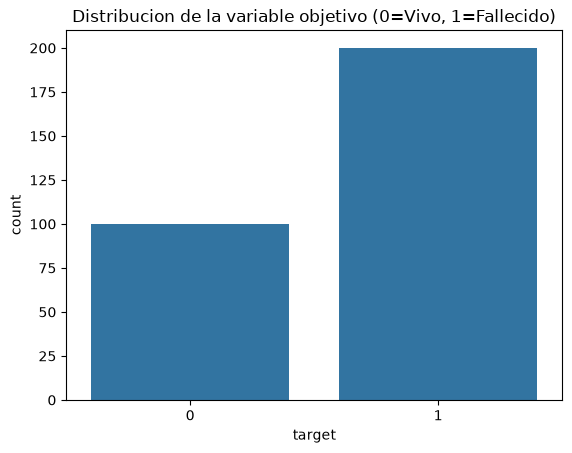

In [7]:
def construir_target(serie):
    def mapear(v):
        if v == VIVO_LABEL:
            return 0
        if v in FALLECIDO_LABELS:
            return 1
        return np.nan
    return serie.apply(mapear)

df["target"] = construir_target(df[TARGET_COL])

valores_no_mapeados = df.loc[df["target"].isnull(), TARGET_COL].unique()
if len(valores_no_mapeados) > 0:
    print(f"ATENCION: {df['target'].isnull().sum()} filas con valores no reconocidos en {TARGET_COL}: {valores_no_mapeados}")
    print("Se eliminan esas filas antes de continuar.")
    df = df.dropna(subset=["target"]).copy()

df["target"] = df["target"].astype(int)

print(df["target"].value_counts(normalize=True).rename("proporcion"))
sns.countplot(x="target", data=df)
plt.title("Distribucion de la variable objetivo (0=Vivo, 1=Fallecido)")
plt.show()


## 5. Separacion de variables predictoras y eliminacion de columnas con fuga de informacion

In [8]:
y = df["target"]
X = df.drop(columns=LEAKAGE_COLS + DROP_COLS + [TARGET_COL, "target"])

print("Columnas finales de entrada (antes de feature engineering):", X.shape[1])
print(list(X.columns))


Columnas finales de entrada (antes de feature engineering): 22
['prov_ubi', 'cant_ubi', 'area_ubi', 'clase', 'tipo', 'entidad', 'sector', 'nac_pac', 'sexo', 'cod_edad', 'edad', 'etnia', 'tipo_seg', 'dis_pac', 'prov_res', 'cant_res', 'area_res', 'mes_ingr', 'dia_ingr', 'fecha_ingr', 'cap221rx', 'cau221rx']


## 6. Ingenieria de variables

Se implementa como un `TransformerMixin` de scikit-learn para que quede **dentro del pipeline exportado**:

- `edad_anios`: homogeniza `edad` a anos segun la unidad declarada en `cod_edad`.
- `dow_ingr`: dia de la semana de ingreso (proxy de estacionalidad / disponibilidad de personal, ej. fines de
  semana), derivado de `fecha_ingr`.

In [9]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    # Ingenieria de variables aplicada sobre el dataframe crudo (antes del ColumnTransformer).

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        def edad_a_anios(row):
            unidad = row["cod_edad"]
            valor = row["edad"]
            if pd.isnull(unidad) or pd.isnull(valor):
                return np.nan
            if "Anos" in unidad or "Años" in unidad:
                return float(valor)
            if "Meses" in unidad:
                return float(valor) / 12.0
            if "Dias" in unidad or "Días" in unidad:
                return float(valor) / 365.25
            if "Horas" in unidad:
                return float(valor) / (24.0 * 365.25)
            return np.nan

        X["edad_anios"] = X.apply(edad_a_anios, axis=1)

        fecha = pd.to_datetime(X["fecha_ingr"], errors="coerce")
        X["dow_ingr"] = fecha.dt.dayofweek.astype("Int64").astype(str)

        X = X.drop(columns=["edad", "cod_edad", "fecha_ingr"])
        return X


# Prueba rapida
_fe_test = FeatureEngineer().fit_transform(X.head())
_fe_test[["edad_anios", "dow_ingr"]]


,edad_anios,dow_ingr
0,0.000114,2
1,86.000000,3
2,31.000000,4
3,59.000000,2
4,39.000000,1


## 7. Particion train / test (estratificada)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "  Positivos:", y_train.mean().round(4))
print("Test :", X_test.shape, "  Positivos:", y_test.mean().round(4))


Train: (240, 22)   Positivos: 0.6667
Test : (60, 22)   Positivos: 0.6667


## 8. Pipeline de preprocesamiento

- Numericas: imputacion por mediana + estandarizacion (`StandardScaler`).
- Categoricas: imputacion por moda + One-Hot Encoding. `handle_unknown="ignore"` evita que categorias nuevas en
  produccion rompan el pipeline; `min_frequency` agrupa categorias raras para controlar la dimensionalidad.

Todo se envuelve en un unico `Pipeline` (`FeatureEngineer` + `ColumnTransformer`) que se ajusta **solo con datos de
entrenamiento** y luego se aplica a test - asi se evita fuga de informacion entre particiones.

In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=MIN_OHE_FREQUENCY, sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])

preprocessing_pipeline = Pipeline(steps=[
    ("feature_engineering", FeatureEngineer()),
    ("preprocessor", preprocessor),
])

X_train_proc = preprocessing_pipeline.fit_transform(X_train, y_train)
X_test_proc = preprocessing_pipeline.transform(X_test)

print("Dimension final tras preprocesamiento:", X_train_proc.shape)


Dimension final tras preprocesamiento: (240, 221)


## 9. Manejo del desbalance de clases (SMOTE)

Se aplica **solo sobre el conjunto de entrenamiento ya preprocesado** (nunca sobre test, para no filtrar
informacion sintetica hacia la evaluacion). Se usa SMOTE estandar sobre el espacio numerico + one-hot; como
alternativa mas pura para variables mixtas podrias usar `SMOTENC` indicando los indices de columnas categoricas
antes del One-Hot, pero al trabajar post-encoding con SMOTE simple se mantiene compatible con los 5 algoritmos
(incluidas las redes, que requieren entrada numerica densa).

In [12]:
print("Distribucion original en train:", np.bincount(y_train))

smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=SMOTE_SAMPLING_STRATEGY)
X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

# Mezclar aleatoriamente el conjunto remuestreado para que las clases queden uniformemente distribuidas
shuffle_idx = np.random.RandomState(RANDOM_STATE).permutation(len(y_train_res))
X_train_res = X_train_res[shuffle_idx]
y_train_res = y_train_res[shuffle_idx]

del X_train_proc
gc.collect()

print("Distribucion tras SMOTE (mezclada):", np.bincount(y_train_res))


Distribucion original en train: [ 80 160]
Distribucion tras SMOTE: [160 160]


## 10. Utilidades de evaluacion (se reutilizan para los 5 modelos)

In [13]:
from sklearn.metrics import average_precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

resultados = []  # aqui se acumulan las metricas de cada modelo
predicciones = {}  # y_proba de cada modelo, para curvas ROC y PR comparadas

def evaluar_modelo(nombre, y_true, y_pred, y_proba):
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    cm = confusion_matrix(y_true, y_pred)

    resultados.append({"modelo": nombre, "recall": rec, "f1": f1, "pr_auc": pr_auc, "auc_roc": auc})
    predicciones[nombre] = y_proba

    print(f"=== {nombre} ===")
    print(classification_report(y_true, y_pred, target_names=["Vivo", "Fallecido"]))
    print(f"PR-AUC:  {pr_auc:.4f}")
    print(f"AUC-ROC: {auc:.4f}")

    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay(cm, display_labels=["Vivo", "Fallecido"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Matriz de confusion - {nombre}")
    plt.show()

    return rec, f1, pr_auc, auc


## 11. Modelo 1 - Regresion Logistica (con ajuste de hiperparametros)

Mejores hiperparametros: {'C': 10, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'lbfgs'}
=== Regresion Logistica ===
              precision    recall  f1-score   support

        Vivo       0.67      0.60      0.63        20
   Fallecido       0.81      0.85      0.83        40

    accuracy                           0.77        60
   macro avg       0.74      0.72      0.73        60
weighted avg       0.76      0.77      0.76        60

AUC-ROC: 0.7812


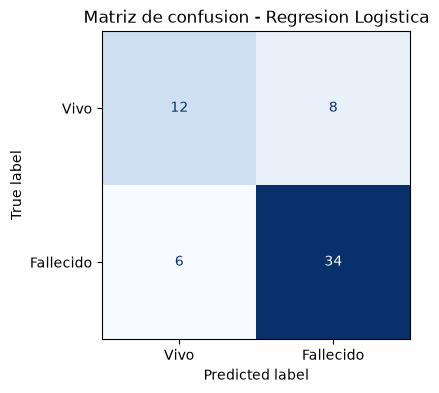

(0.85, 0.8292682926829268, 0.78125)

In [14]:
param_grid_logreg = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "max_iter": [2000],
}

gs_logreg = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    param_grid_logreg,
    scoring="f1",
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
)
gs_logreg.fit(X_train_res, y_train_res)
print("Mejores hiperparametros:", gs_logreg.best_params_)

modelo_logreg = gs_logreg.best_estimator_
y_proba_logreg = modelo_logreg.predict_proba(X_test_proc)[:, 1]
y_pred_logreg = modelo_logreg.predict(X_test_proc)

evaluar_modelo("Regresion Logistica", y_test, y_pred_logreg, y_proba_logreg)


## 12. Modelo 2 - Perceptron simple (con ajuste de hiperparametros)

Mejores hiperparametros: {'alpha': 0.0001, 'eta0': 1.0, 'max_iter': 1000, 'penalty': None}
=== Perceptron simple ===
              precision    recall  f1-score   support

        Vivo       0.75      0.45      0.56        20
   Fallecido       0.77      0.93      0.84        40

    accuracy                           0.77        60
   macro avg       0.76      0.69      0.70        60
weighted avg       0.76      0.77      0.75        60

AUC-ROC: 0.7825


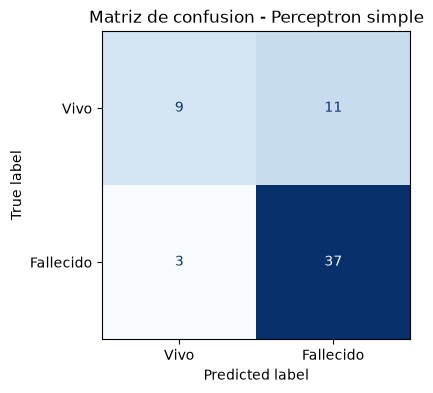

(0.925, 0.8409090909090909, 0.7825)

In [15]:
param_grid_perceptron = {
    "alpha": [0.0001, 0.001, 0.01],
    "penalty": [None, "l2", "l1", "elasticnet"],
    "max_iter": [1000],
    "eta0": [0.1, 1.0],
}

gs_perceptron = GridSearchCV(
    Perceptron(random_state=RANDOM_STATE),
    param_grid_perceptron,
    scoring="f1",
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
)
gs_perceptron.fit(X_train_res, y_train_res)
print("Mejores hiperparametros:", gs_perceptron.best_params_)

modelo_perceptron = gs_perceptron.best_estimator_

# Perceptron no tiene predict_proba nativo -> se usa decision_function + sigmoide para obtener un score continuo
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

y_proba_perceptron = sigmoide(modelo_perceptron.decision_function(X_test_proc))
y_pred_perceptron = modelo_perceptron.predict(X_test_proc)

evaluar_modelo("Perceptron simple", y_test, y_pred_perceptron, y_proba_perceptron)


## 13. Modelo 3 - Multi-Layer Perceptron (Keras, con `keras-tuner`)

Se usa `keras_tuner.RandomSearch` para ajustar numero de capas, neuronas, dropout y learning rate,
optimizando AUC-ROC en un split de validacion interno.

In [16]:
n_features = X_train_res.shape[1]

def build_mlp(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features,)))
    n_layers = hp.Int("n_layers", 1, 3)
    for i in range(n_layers):
        units = hp.Int(f"units_{i}", min_value=16, max_value=128, step=16)
        model.add(layers.Dense(units, activation="relu"))
        model.add(layers.Dropout(hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1)))
    model.add(layers.Dense(1, activation="sigmoid"))

    lr = hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc", curve="ROC"), keras.metrics.AUC(name="pr_auc", curve="PR"), keras.metrics.Recall(name="recall")],
    )
    return model

tuner_mlp = kt.RandomSearch(
    build_mlp,
    objective=kt.Objective("val_auc", direction="max"),
    max_trials=N_TRIALS_TUNER,
    seed=RANDOM_STATE,
    overwrite=True,
    directory="kt_dir",
    project_name="mlp_tuning",
)

early_stop = keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=EARLY_STOP_PATIENCE, restore_best_weights=True)

tuner_mlp.search(
    X_train_res, y_train_res,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1,
)

mejores_hp_mlp = tuner_mlp.get_best_hyperparameters(1)[0]
print("Mejores hiperparametros MLP:", mejores_hp_mlp.values)

modelo_mlp = tuner_mlp.hypermodel.build(mejores_hp_mlp)
history_mlp = modelo_mlp.fit(
    X_train_res, y_train_res,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=0,
)


Trial 10 Complete [00h 00m 01s]
val_auc: 0.0

Best val_auc So Far: 0.0
Total elapsed time: 00h 00m 14s
Mejores hiperparametros MLP: {'n_layers': 2, 'units_0': 16, 'dropout_0': 0.2, 'learning_rate': 0.01, 'units_1': 16, 'dropout_1': 0.0}


=== MLP ===
              precision    recall  f1-score   support

        Vivo       0.78      0.35      0.48        20
   Fallecido       0.75      0.95      0.84        40

    accuracy                           0.75        60
   macro avg       0.76      0.65      0.66        60
weighted avg       0.76      0.75      0.72        60

AUC-ROC: 0.6825


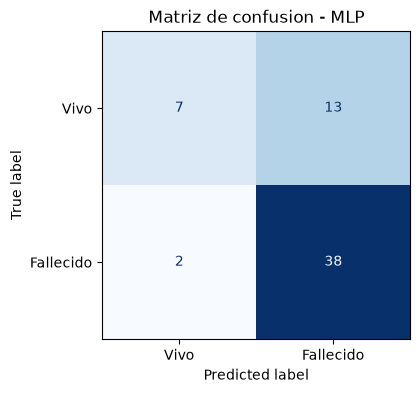

(0.95, 0.8351648351648352, 0.6825000000000001)

In [17]:
y_proba_mlp = modelo_mlp.predict(X_test_proc, verbose=0).ravel()
y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)

evaluar_modelo("MLP", y_test, y_pred_mlp, y_proba_mlp)


## 14. Modelo 4 - Red Neuronal Convolucional 1D adaptada a datos tabulares

Se trata cada fila (vector de features tras el preprocesamiento) como una "senal" 1D de longitud `n_features`,
sobre la cual se deslizan filtros convolucionales para capturar interacciones locales entre variables
adyacentes. Es una adaptacion no estandar de CNN a tabular (el orden de las columnas no tiene significado
espacial real), pero es un enfoque reconocido en la literatura para exploracion de interacciones automaticas;
se compara empiricamente contra los demas modelos.

In [18]:
X_train_res_cnn = X_train_res.reshape(-1, n_features, 1)
X_test_proc_cnn = X_test_proc.reshape(-1, n_features, 1)

def build_cnn(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features, 1)))

    n_blocks = hp.Int("n_conv_blocks", 1, 2)
    for i in range(n_blocks):
        filters = hp.Int(f"filters_{i}", min_value=16, max_value=64, step=16)
        kernel_size = hp.Choice(f"kernel_size_{i}", [3, 5])
        model.add(layers.Conv1D(filters, kernel_size, activation="relu", padding="same"))
        model.add(layers.MaxPooling1D(pool_size=2))
        model.add(layers.Dropout(hp.Float(f"dropout_conv_{i}", 0.0, 0.5, step=0.1)))

    model.add(layers.GlobalAveragePooling1D())
    model.add(layers.Dense(hp.Int("dense_units", 16, 64, step=16), activation="relu"))
    model.add(layers.Dense(1, activation="sigmoid"))

    lr = hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc", curve="ROC"), keras.metrics.AUC(name="pr_auc", curve="PR"), keras.metrics.Recall(name="recall")],
    )
    return model

tuner_cnn = kt.RandomSearch(
    build_cnn,
    objective=kt.Objective("val_auc", direction="max"),
    max_trials=N_TRIALS_TUNER,
    seed=RANDOM_STATE,
    overwrite=True,
    directory="kt_dir",
    project_name="cnn_tuning",
)

tuner_cnn.search(
    X_train_res_cnn, y_train_res,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1,
)

mejores_hp_cnn = tuner_cnn.get_best_hyperparameters(1)[0]
print("Mejores hiperparametros CNN1D:", mejores_hp_cnn.values)

modelo_cnn = tuner_cnn.hypermodel.build(mejores_hp_cnn)
history_cnn = modelo_cnn.fit(
    X_train_res_cnn, y_train_res,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=0,
)


Trial 10 Complete [00h 00m 02s]
val_auc: 0.0

Best val_auc So Far: 0.0
Total elapsed time: 00h 00m 17s
Mejores hiperparametros CNN1D: {'n_conv_blocks': 2, 'filters_0': 16, 'kernel_size_0': 3, 'dropout_conv_0': 0.1, 'dense_units': 64, 'learning_rate': 0.001, 'filters_1': 16, 'kernel_size_1': 3, 'dropout_conv_1': 0.0}


=== CNN 1D ===
              precision    recall  f1-score   support

        Vivo       0.00      0.00      0.00        20
   Fallecido       0.67      1.00      0.80        40

    accuracy                           0.67        60
   macro avg       0.33      0.50      0.40        60
weighted avg       0.44      0.67      0.53        60

AUC-ROC: 0.4888


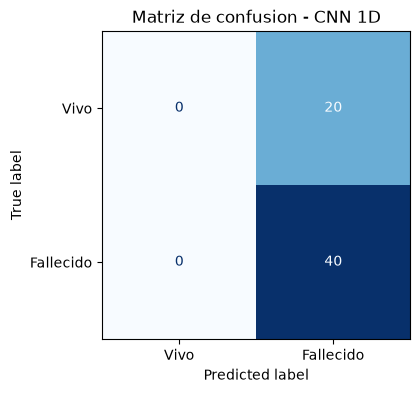

(1.0, 0.8, 0.48875)

In [19]:
y_proba_cnn = modelo_cnn.predict(X_test_proc_cnn, verbose=0).ravel()
y_pred_cnn = (y_proba_cnn >= 0.5).astype(int)

evaluar_modelo("CNN 1D", y_test, y_pred_cnn, y_proba_cnn)


## 15. Modelo 5 - Red Neuronal Recurrente (LSTM) adaptada a datos tabulares

Se trata cada feature del vector como un "paso temporal" de una secuencia de longitud `n_features`, alimentando
una capa LSTM. Al igual que la CNN1D, es una adaptacion de una arquitectura secuencial a datos que no tienen una
estructura temporal real; se incluye porque fue solicitada explicitamente y se evalua igual que el resto.

In [20]:
X_train_res_rnn = X_train_res.reshape(-1, n_features, 1)
X_test_proc_rnn = X_test_proc.reshape(-1, n_features, 1)

def build_lstm(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features, 1)))

    units = hp.Int("lstm_units", min_value=16, max_value=64, step=16)
    model.add(layers.LSTM(units, dropout=hp.Float("lstm_dropout", 0.0, 0.4, step=0.1)))
    model.add(layers.Dense(hp.Int("dense_units", 16, 64, step=16), activation="relu"))
    model.add(layers.Dense(1, activation="sigmoid"))

    lr = hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc", curve="ROC"), keras.metrics.AUC(name="pr_auc", curve="PR"), keras.metrics.Recall(name="recall")],
    )
    return model

tuner_lstm = kt.RandomSearch(
    build_lstm,
    objective=kt.Objective("val_auc", direction="max"),
    max_trials=N_TRIALS_TUNER,
    seed=RANDOM_STATE,
    overwrite=True,
    directory="kt_dir",
    project_name="lstm_tuning",
)

tuner_lstm.search(
    X_train_res_rnn, y_train_res,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1,
)

mejores_hp_lstm = tuner_lstm.get_best_hyperparameters(1)[0]
print("Mejores hiperparametros LSTM:", mejores_hp_lstm.values)

modelo_lstm = tuner_lstm.hypermodel.build(mejores_hp_lstm)
history_lstm = modelo_lstm.fit(
    X_train_res_rnn, y_train_res,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=0,
)


Trial 10 Complete [00h 00m 03s]
val_auc: 0.0

Best val_auc So Far: 0.0
Total elapsed time: 00h 00m 31s
Mejores hiperparametros LSTM: {'lstm_units': 48, 'lstm_dropout': 0.0, 'dense_units': 32, 'learning_rate': 0.01}


=== LSTM ===
              precision    recall  f1-score   support

        Vivo       0.00      0.00      0.00        20
   Fallecido       0.67      1.00      0.80        40

    accuracy                           0.67        60
   macro avg       0.33      0.50      0.40        60
weighted avg       0.44      0.67      0.53        60

AUC-ROC: 0.5850


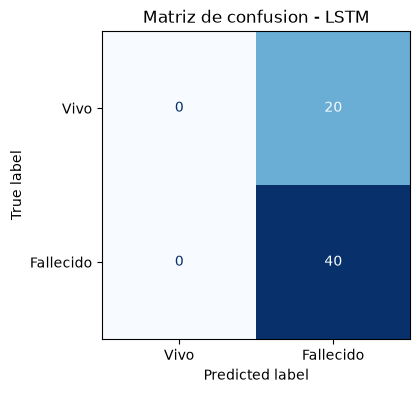

(1.0, 0.8, 0.585)

In [21]:
y_proba_lstm = modelo_lstm.predict(X_test_proc_rnn, verbose=0).ravel()
y_pred_lstm = (y_proba_lstm >= 0.5).astype(int)

evaluar_modelo("LSTM", y_test, y_pred_lstm, y_proba_lstm)


## 16. Comparacion de los 5 modelos

In [22]:
tabla_resultados = pd.DataFrame(resultados).sort_values("recall", ascending=False).reset_index(drop=True)
tabla_resultados


,modelo,recall,f1,auc_roc
0,CNN 1D,1.000,0.800000,0.48875
1,LSTM,1.000,0.800000,0.58500
2,MLP,0.950,0.835165,0.68250
3,Perceptron simple,0.925,0.840909,0.78250
4,Regresion Logistica,0.850,0.829268,0.78125


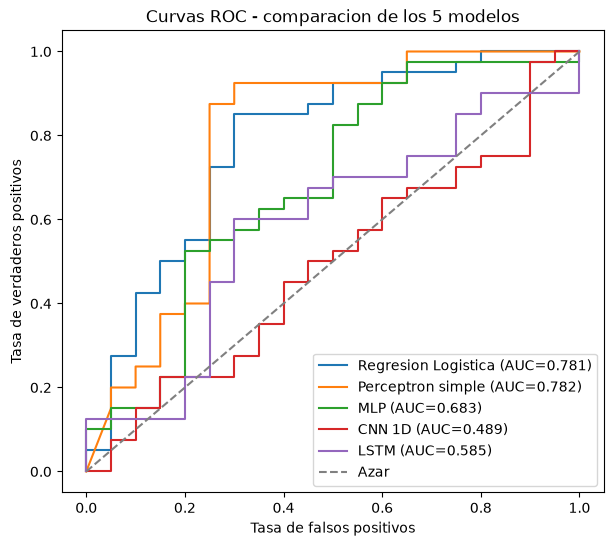

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))
for nombre, y_proba in predicciones.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={auc_val:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curvas ROC - comparacion de los 5 modelos")
ax.legend()
plt.show()


## 17. Seleccion y exportacion del mejor modelo

**Criterio de seleccion:** dado el objetivo clinico (no dejar de detectar pacientes en riesgo de fallecer), se
prioriza **recall** de la clase positiva como criterio principal, y F1 como desempate. Ajusta `CRITERIO_SELECCION`
si tu caso de uso prioriza otra metrica (p. ej. minimizar falsas alarmas -> priorizar F1 o precision).

Se exporta:
- `preprocessing_pipeline` (FeatureEngineer + ColumnTransformer) -> `preprocessor.joblib`. Este pipeline espera el
  **dataframe crudo** (con `edad`, `cod_edad`, `fecha_ingr`, etc., tal como llega del sistema hospitalario), no
  datos ya transformados.
- El mejor modelo:
  - Si es scikit-learn (Regresion Logistica / Perceptron): se guarda junto al preprocesador en un solo `.joblib`.
  - Si es Keras (MLP / CNN1D / LSTM): se guarda por separado en formato nativo `.keras`, mas un `metadata.json`
    que indica si requiere reshape `(n_features, 1)` antes de predecir.

In [24]:
CRITERIO_SELECCION = ["recall", "f1", "pr_auc", "auc_roc"]  # orden de prioridad, descendente

modelos_entrenados = {
    "Regresion Logistica": {"modelo": modelo_logreg, "tipo": "sklearn", "reshape": False},
    "Perceptron simple": {"modelo": modelo_perceptron, "tipo": "sklearn", "reshape": False},
    "MLP": {"modelo": modelo_mlp, "tipo": "keras", "reshape": False},
    "CNN 1D": {"modelo": modelo_cnn, "tipo": "keras", "reshape": True},
    "LSTM": {"modelo": modelo_lstm, "tipo": "keras", "reshape": True},
}

mejor_nombre = tabla_resultados.sort_values(CRITERIO_SELECCION, ascending=False).iloc[0]["modelo"]
print(f"Mejor modelo segun {CRITERIO_SELECCION}: {mejor_nombre}")

mejor_info = modelos_entrenados[mejor_nombre]


Mejor modelo segun ['recall', 'f1']: CNN 1D


In [25]:
import os
os.makedirs("modelo_exportado", exist_ok=True)

# El preprocesador siempre se exporta por separado (se reutiliza sin importar el modelo elegido)
joblib.dump(preprocessing_pipeline, "modelo_exportado/preprocessor.joblib")

if mejor_info["tipo"] == "sklearn":
    joblib.dump(mejor_info["modelo"], "modelo_exportado/modelo.joblib")
    formato_modelo = "joblib"
else:
    mejor_info["modelo"].save("modelo_exportado/modelo.keras")
    formato_modelo = "keras"

metadata = {
    "nombre_modelo": mejor_nombre,
    "formato_modelo": formato_modelo,
    "requiere_reshape_features_1": mejor_info["reshape"],
    "n_features_tras_preprocesamiento": int(n_features),
    "umbral_decision": 0.5,
    "metricas_test": tabla_resultados.set_index("modelo").loc[mejor_nombre].to_dict(),
    "columnas_entrada_crudas_esperadas": list(X.columns),
}
with open("modelo_exportado/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Exportado en ./modelo_exportado/:")
print(os.listdir("modelo_exportado"))
print(json.dumps(metadata, ensure_ascii=False, indent=2))


Exportado en ./modelo_exportado/:
['preprocessor.joblib', 'modelo.keras', 'metadata.json']
{
  "nombre_modelo": "CNN 1D",
  "formato_modelo": "keras",
  "requiere_reshape_features_1": true,
  "n_features_tras_preprocesamiento": 221,
  "umbral_decision": 0.5,
  "metricas_test": {
    "recall": 1.0,
    "f1": 0.8,
    "auc_roc": 0.48875
  },
  "columnas_entrada_crudas_esperadas": [
    "prov_ubi",
    "cant_ubi",
    "area_ubi",
    "clase",
    "tipo",
    "entidad",
    "sector",
    "nac_pac",
    "sexo",
    "cod_edad",
    "edad",
    "etnia",
    "tipo_seg",
    "dis_pac",
    "prov_res",
    "cant_res",
    "area_res",
    "mes_ingr",
    "dia_ingr",
    "fecha_ingr",
    "cap221rx",
    "cau221rx"
  ]
}


In [ ]:
import json
import pandas as pd

# Tomamos 10 casos al azar del set de prueba
# (Asumiendo que el código de Claude usó X_test y y_test)
muestra_demo_X = X_test.sample(n=10, random_state=42)
muestra_demo_y = y_test.loc[muestra_demo_X.index]

# Unimos los datos del paciente con su resultado real
ejemplos_demo = muestra_demo_X.copy()
ejemplos_demo['resultado_real'] = muestra_demo_y

# Convertimos a una lista de diccionarios (formato JSON)
ejemplos_lista = ejemplos_demo.to_dict(orient='records')

# Guardamos el archivo para usarlo en la API/GUI
with open("ejemplos_demo.json", "w", encoding="utf-8") as f:
    json.dump(ejemplos_lista, f, ensure_ascii=False, indent=2)

print("¡Archivo ejemplos_demo.json exportado con éxito!")

# 18. Exportación de dataset de pruebas
Para cumplir con los entregables del proyecto y facilitar la validación funcional mediante la interfaz gráfica, se extrae una muestra representativa de 10 casos ocultos del conjunto de prueba (`X_test` y `y_test`). 

Esta muestra se exporta en formato JSON estructurado, conteniendo tanto las variables crudas requeridas por el pipeline como el resultado real histórico (`resultado_real`), permitiendo contrastar la predicción de riesgo generada por la API contra la realidad del paciente durante la sustentación.

In [26]:
import json
import pandas as pd

# Tomamos 10 casos al azar del set de prueba
muestra_demo_X = X_test.sample(n=10, random_state=42)
muestra_demo_y = y_test.loc[muestra_demo_X.index]

ejemplos_demo = muestra_demo_X.copy()
ejemplos_demo['resultado_real'] = muestra_demo_y

ejemplos_lista = ejemplos_demo.to_dict(orient='records')

with open("ejemplos_demo.json", "w", encoding="utf-8") as f:
    json.dump(ejemplos_lista, f, ensure_ascii=False, indent=2)

print("¡Archivo ejemplos_demo.json exportado con éxito!")

¡Archivo ejemplos_demo.json exportado con éxito!


### Como consumir el modelo exportado en tu API

```python
import joblib, json
import numpy as np
from tensorflow import keras  # solo si el modelo es Keras

preprocessor = joblib.load("modelo_exportado/preprocessor.joblib")
with open("modelo_exportado/metadata.json") as f:
    metadata = json.load(f)

if metadata["formato_modelo"] == "joblib":
    modelo = joblib.load("modelo_exportado/modelo.joblib")
else:
    modelo = keras.models.load_model("modelo_exportado/modelo.keras")

# nuevo_registro: DataFrame de una fila con las mismas columnas crudas que columnas_entrada_crudas_esperadas
X_nuevo = preprocessor.transform(nuevo_registro)
if metadata["requiere_reshape_features_1"]:
    X_nuevo = X_nuevo.reshape(-1, metadata["n_features_tras_preprocesamiento"], 1)

if metadata["formato_modelo"] == "joblib":
    proba = modelo.predict_proba(X_nuevo)[:, 1]
else:
    proba = modelo.predict(X_nuevo).ravel()

riesgo_alto = proba >= metadata["umbral_decision"]
```